# Forum Page Views Visualizer

In [199]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Import & Filter the Dataset
---

- The data is read from a CSV file, and the 'date' column is parsed as a datetime object and set as the index of the dataframe.
- We then clean the data by filtering out the extreme outliers. We retain only the data that falls between the 2.5th and 97.5th percentiles to remove extreme spikes.

In [202]:
df = pd.read_csv("fcc-forum-pageviews.csv", index_col = 'date', parse_dates=True)

In [204]:
df.head()

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1304 entries, 2016-05-09 to 2019-12-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   1304 non-null   int64
dtypes: int64(1)
memory usage: 20.4 KB


In [208]:
# Clean data
lower_thresh = df['value'].quantile(0.025)
upper_thresh = df['value'].quantile(0.975)
df = df[(df['value'] >= lower_thresh) & (df['value'] <= upper_thresh)]

### Line Plot Visualization

- Create a line plot to visualize the daily page views on the freeCodeCamp forum
- The plot spans from May 2016 to December 2019.
- The date is plotted on the x-axis, and the page views are plotted on the y-axis.

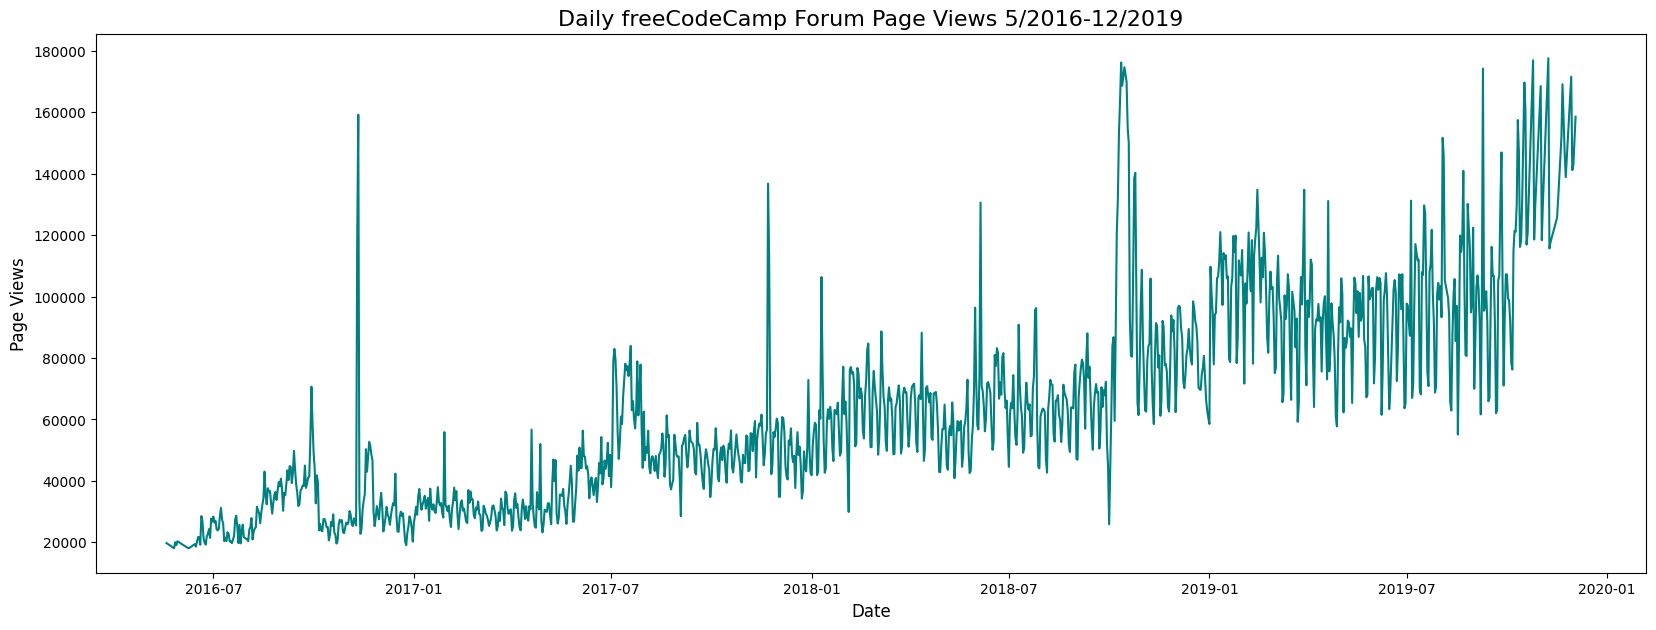

In [212]:
# Draw line plot
fig, ax = plt.subplots(figsize=(20,7))
df_copy = df.copy()
ax.plot(df_copy.index, df_copy['value'], color='teal')
plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019', fontsize=16)
plt.xlabel('Date',fontsize=12)
plt.ylabel('Page Views',fontsize=12)
plt.show()

In [214]:
fig.savefig('line_plot.png')

### Monthly Page Views
---

- Create a monthly bar plot showing the average page views per month for each year
- We first group the data by year and month and calculate the average page views
- The months are displayed in chronological order on the x-axis, and the bar heights represent the average views for each month.
- The bar chart is grouped by year.

**Add new columns and reshape the dataframe**

In [219]:
df_bar = df.copy()
df_bar.reset_index(inplace=True)
df_bar['month'] = df_bar.date.dt.strftime("%B")
df_bar['year'] = df_bar.date.dt.year
df_grouped = df_bar.groupby(['year', 'month'])['value'].mean().unstack()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df_grouped = df_grouped[month_order]

In [221]:
my_cmap = plt.get_cmap("tab20c", len(month_order))

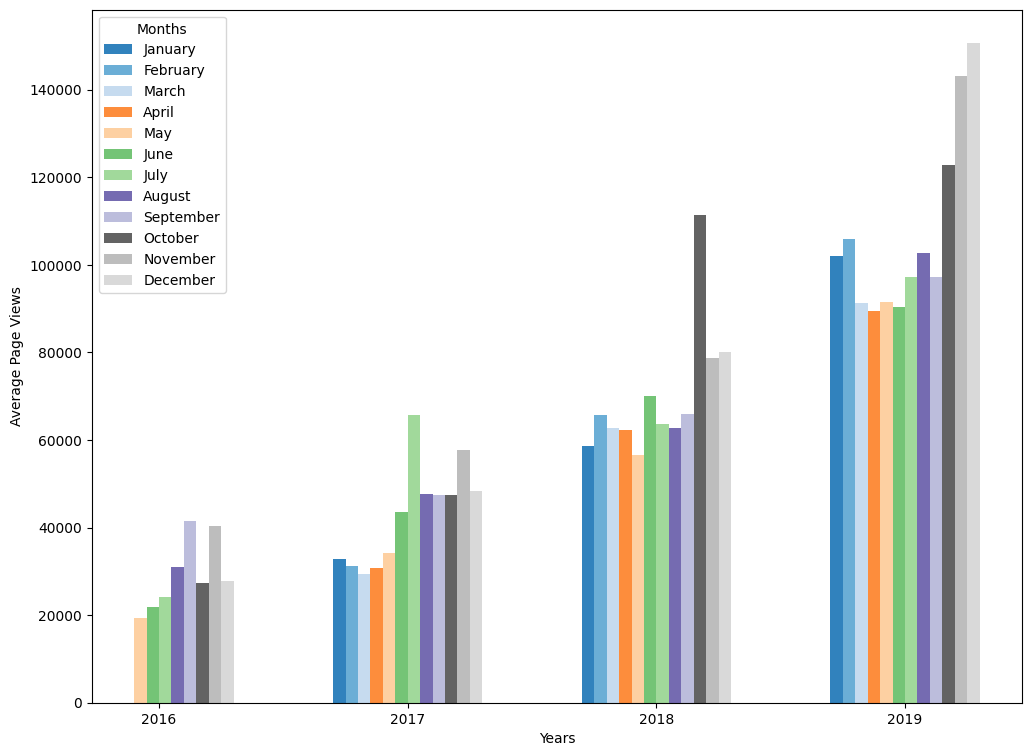

In [223]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111)

width = 0.05  
x = np.arange(len(df_grouped.index))
for i, month in enumerate(month_order):
    ax.bar(x + i * width, df_grouped[month], width, label=month, color=my_cmap(i))
    
ax.set_ylabel('Average Page Views')
ax.set_xlabel('Years')
ax.set_xticks(x + width * 5.5)  
ax.set_xticklabels(df_grouped.index)
plt.legend(title='Months', loc='upper left')

In [225]:
fig.savefig('bar_plot.png')

### Yearly & Monthly EDA
---

This section creates 2 new plots:
1. **Year-wise box plot:** Shows the distribution of page views for each year, highlighting trends over time.
2. **Month-wise box plot:** Displays the distribution of page views for each month, revealing any seasonal patterns in the data.

The box plots help visualize the spread and outliers in the data.

**Prepare and reshape data**

In [230]:
df_box = df.copy()
df_box.reset_index(inplace=True)
df_box['year'] = [d.year for d in df_box.date]
df_box['month'] = [d.strftime('%b') for d in df_box.date]
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df_box['month'] = pd.Categorical(df_box['month'], ordered=True, categories=months)

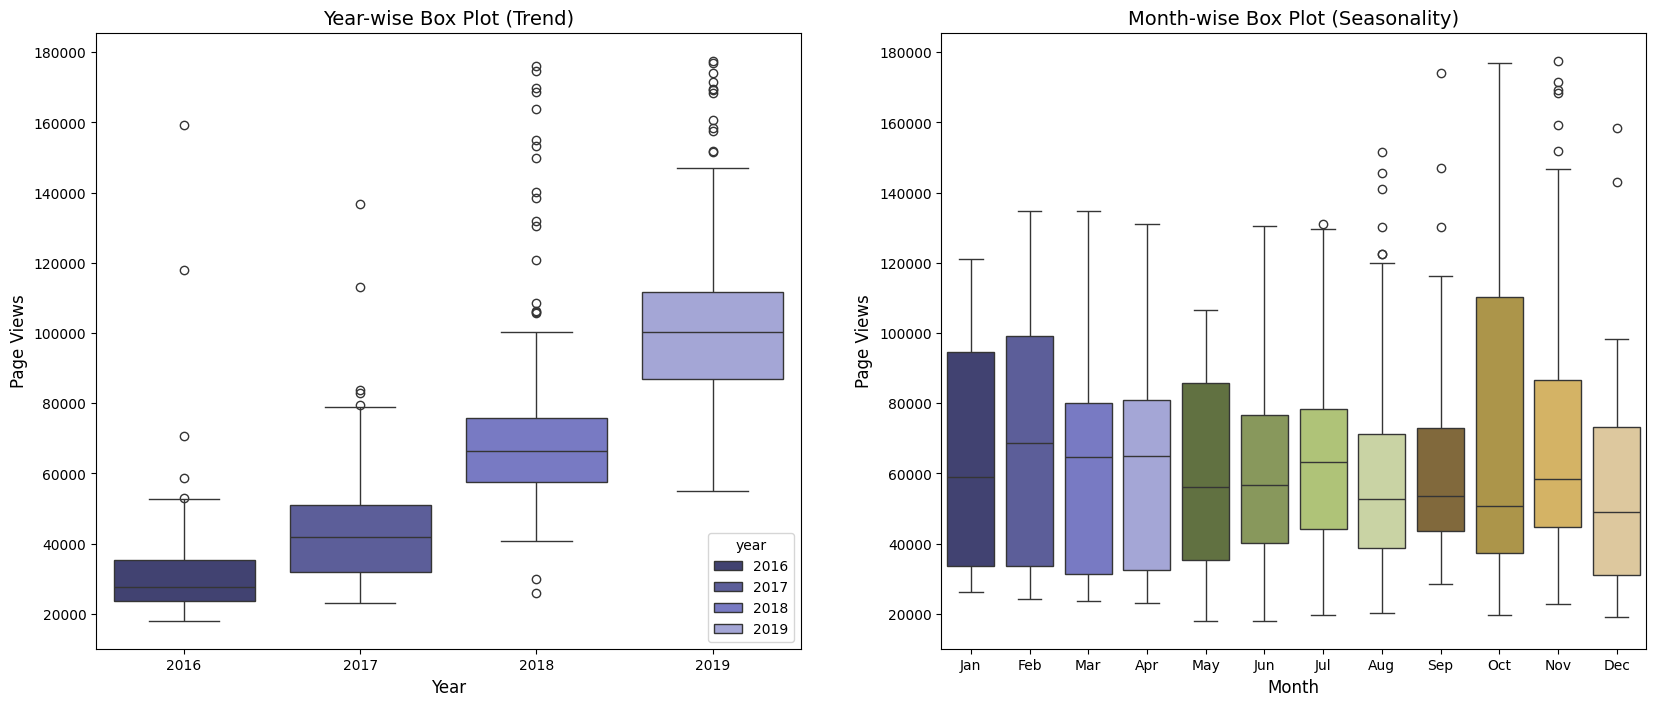

In [232]:
# Draw box plots (using Seaborn)
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,8))
sns.boxplot(data=df_box, x='year', y='value', ax=ax1, hue='year', palette="tab20b")
ax1.set_title('Year-wise Box Plot (Trend)', fontsize=14)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Page Views', fontsize=12)

sns.boxplot(data=df_box, x='month', y='value', ax=ax2, hue='month', palette="tab20b")
ax2.set_title('Month-wise Box Plot (Seasonality)', fontsize=14)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Page Views', fontsize=12)

plt.show()

In [234]:
fig = plt.gcf()
fig.savefig('box_plot.png')

<Figure size 640x480 with 0 Axes>

---

# Sea Level Prediction

We begin by importing the necessary libraries:

- `pandas` for data manipulation and loading the CSV file.
- `numpy` for numerical operations.
- `matplotlib.pyplot` for plotting and creating visualizations.
- `scipy.stats.linregress` for performing linear regression and fitting lines to the data.

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

Here, we load the sea level dataset into a pandas DataFrame from a CSV file named epa-sea-level.csv. The dataset contains historical sea level data.

In [242]:
df = pd.read_csv("../Sea level predictor/epa-sea-level.csv", 
                 usecols=['Year', 'CSIRO Adjusted Sea Level','Lower Error Bound', 'Upper Error Bound'])

In [244]:
df.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound
0,1880,0.000000,-0.952756,0.952756
1,1881,0.220472,-0.732283,1.173228
2,1882,-0.440945,-1.346457,0.464567
3,1883,-0.232283,-1.129921,0.665354
4,1884,0.590551,-0.283465,1.464567


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      134 non-null    int64  
 1   CSIRO Adjusted Sea Level  134 non-null    float64
 2   Lower Error Bound         134 non-null    float64
 3   Upper Error Bound         134 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 4.3 KB


---
* The first line of best fit is calculated for the entire dataset using linear regression.
* The linregress function returns the slope and intercept of the line, which are then used to calculate predicted sea levels (y_pred) for each year from the minimum year in the dataset to 2050.
* The best fit line is then plotted in royalblue with the equation displayed in the legend.

In [249]:
# Create first line of best fit
x1 = df['Year']
y1 = df['CSIRO Adjusted Sea Level']
fit = linregress(x1, y1)
extended_years = np.arange(df['Year'].min(), 2051)
y_pred = fit.intercept + fit.slope * extended_years

---
* A second line of best fit is computed, but only for data from the year 2000 onwards.
* Similar to the first line, linregress is used to compute the slope and intercept, and predictions are made for the years 2000 to 2050.
* The second best fit line is plotted in red and displayed on the plot with its equation in the legend.


In [252]:
# Create second line of best fit
x = df.loc[df['Year'] >= 2000, "Year"]
y = df.loc[df['Year'] >= 2000, "CSIRO Adjusted Sea Level"]
fit2 = linregress(x, y)
y_pred2000 = fit2.intercept + fit2.slope * np.arange(2000, 2051)

In [254]:
import matplotlib as mp

A scatter plot is created to visualize the relationship between the year (x-axis) and the CSIRO Adjusted Sea Level (y-axis).

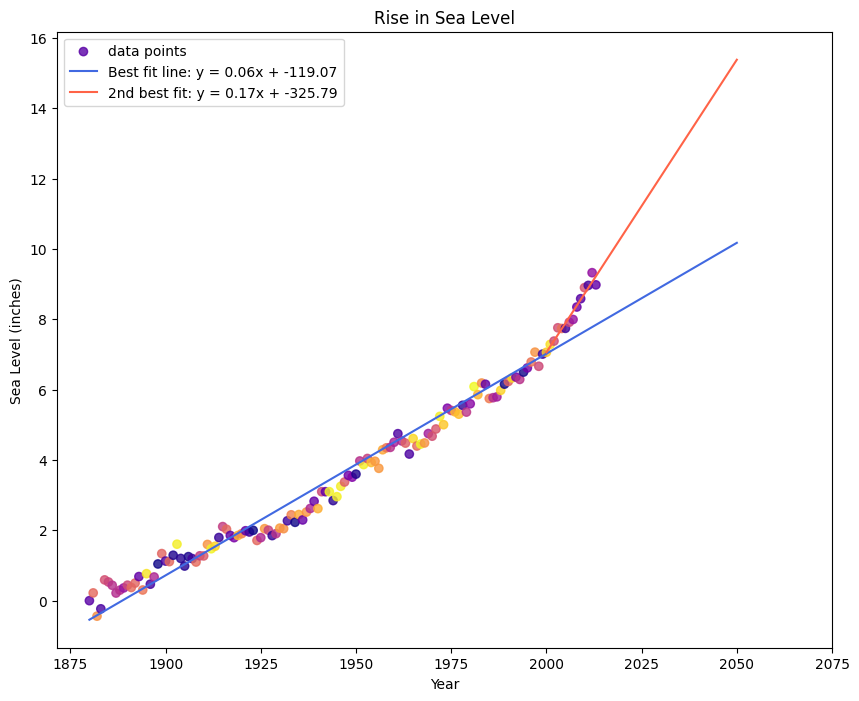

In [257]:
# Create scatter plot
colors = np.random.rand(len(df['Year']))
cmap = mp.colormaps.get_cmap('plasma')
fig = plt.figure(figsize=(10,8))
plt.scatter(df['Year'], df['CSIRO Adjusted Sea Level'], label='data points', alpha=0.8, c=colors, cmap=cmap)

plt.plot(extended_years, y_pred, color="royalblue", label=f"Best fit line: y = {fit.slope:.2f}x + {fit.intercept:.2f}")
plt.plot(np.arange(2000, 2051), y_pred2000, color="tomato", label=f"2nd best fit: y = {fit2.slope:.2f}x + {fit2.intercept:.2f}")

years = np.array([1875.0, 1900.0, 1925.0, 1950.0, 1975.0, 2000.0, 2025.0, 2050.0, 2075.0])
plt.xticks(years)

# Add labels and title
plt.title("Rise in Sea Level")
plt.xlabel("Year")
plt.ylabel("Sea Level (inches)")
plt.legend()

plt.show()

In [259]:
plt.savefig('../Sea level predictor/sea_level_plot.png')

<Figure size 640x480 with 0 Axes>